Ground-state energy = 1.6335240958369295


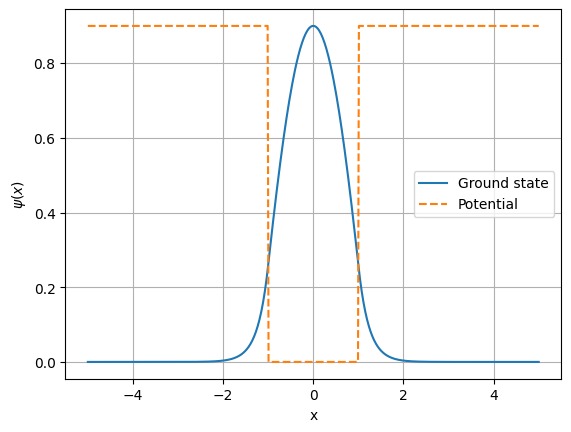

In [1]:
#Analytical method
import numpy as np
import matplotlib.pyplot as plt

N = 500

x_min = -5
x_max = 5

x = np.linspace(x_min, x_max, N)

dx = x[1] - x[0]

V0 = 20.0
a = 1.0

V = np.where(np.abs(x) < a, 0.0, V0)

main_diag = 2*np.ones(N)/dx**2
off_diag = -1*np.ones(N-1)/dx**2
T = (np.diag(main_diag)+ np.diag(off_diag,1)+ np.diag(off_diag,-1))
H = T + np.diag(V)

eigenvalues, eigenvectors = np.linalg.eigh(H)
E0 = eigenvalues[0]
psi0 = eigenvectors[:,0]
norm = np.sqrt(np.sum(psi0**2)*dx)
psi0 = psi0/norm

print("Ground-state energy =", E0)

plt.plot(x, psi0, label="Ground state")
plt.plot(x,V/V0*np.max(np.abs(psi0)),'--',label="Potential")
plt.xlabel("x")
plt.ylabel(r"$\psi(x)$")
plt.legend()
plt.grid()
plt.show()

Epoch    0E = 1.0010Loss = 118.778809
Epoch  500E = 1.0232Loss = 0.867689
Epoch 1000E = 1.1478Loss = 0.592632
Epoch 1500E = 1.3314Loss = 0.525744
Epoch 2000E = 1.5007Loss = 0.507930
Epoch 2500E = 1.6223Loss = 0.422813
Epoch 3000E = 1.6820Loss = 0.364945
Epoch 3500E = 1.6952Loss = 0.334687
Epoch 4000E = 1.6917Loss = 0.323739
Epoch 4500E = 1.6901Loss = 0.313797
Final Energy = 1.6851931810379028


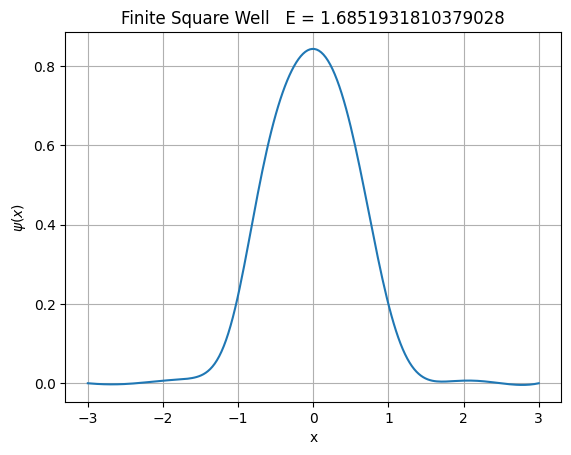

In [14]:
#PINNs approach
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 40)
        self.fc2 = nn.Linear(40, 40)
        self.fc3 = nn.Linear(40, 1)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)
        return x 

def derivative(y, x):
    return torch.autograd.grad( y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]

def potential(x):
    return torch.where(torch.abs(x) <= 1.0,torch.zeros_like(x),20.0 * torch.ones_like(x))

def psi(model, x):
    return (x + 3.0) * (3.0 - x) * model(x)

x = torch.linspace(-3, 3, 200).reshape(-1, 1)
x.requires_grad_(True)

model = Net()

E = nn.Parameter(torch.tensor([1.0]))

optimizer = torch.optim.Adam(list(model.parameters()) + [E],lr=1e-3)

for epoch in range(5000):

    optimizer.zero_grad()

    psi_pred = psi(model, x)

    psi_x = derivative(psi_pred, x)
    psi_xx = derivative(psi_x, x)

    V = potential(x)

    residual = -psi_xx + V * psi_pred - E * psi_pred

    pde_loss = torch.mean(residual ** 2)

    dx = 6.0 / (200 - 1)
    norm = torch.sum(psi_pred**2) * dx
    norm_loss = (norm - 1.0) ** 2
    

    loss = pde_loss + norm_loss

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | E = {E.item()} | Loss = {loss.item()}")
with torch.no_grad():
    psi_nn = psi(model, x).detach().numpy()

x_np = x.detach().numpy()

print("Final Energy =", E.item())

plt.plot(x_np, psi_nn)
plt.xlabel("x")
plt.ylabel(r"$\psi(x)$")
plt.title(f"Finite Square Well   E = {E.item()}")
plt.grid(True)
plt.show()

<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ATHARV\AppData\Local\Temp\ipykernel_20860\1102515908.py:44: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("$\psi(x)$")


Epoch 0 | E = 6.000999927520752 | PDE = 111.39647674560547 | Norm = 3.5152721405029297 | Orth = 1.7292700249527115e-06
Epoch 500 | E = 6.293847560882568 | PDE = 10.318509101867676 | Norm = 0.9317721128463745 | Orth = 5.705821422452573e-06
Epoch 1000 | E = 6.381449222564697 | PDE = 3.0578718185424805 | Norm = 0.9797219038009644 | Orth = 6.079528702684911e-06
Epoch 1500 | E = 6.426208972930908 | PDE = 2.233755111694336 | Norm = 0.9882895946502686 | Orth = 6.83510643284535e-06
Epoch 2000 | E = 6.470818042755127 | PDE = 1.811228632926941 | Norm = 0.9907124042510986 | Orth = 6.202071745065041e-06
Epoch 2500 | E = 6.504951000213623 | PDE = 1.4316229820251465 | Norm = 0.9926315546035767 | Orth = 5.970628990326077e-06
Epoch 3000 | E = 6.526678562164307 | PDE = 1.2217305898666382 | Norm = 0.9937164187431335 | Orth = 6.516877419926459e-06
Epoch 3500 | E = 6.540156364440918 | PDE = 1.1316546201705933 | Norm = 0.9943313598632812 | Orth = 6.9473671828745864e-06
Epoch 4000 | E = 6.549663543701172 | 

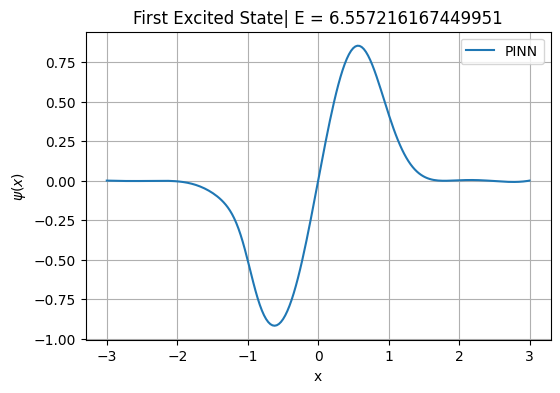

In [29]:
psi_ground = psi(model, x).detach()

model1 = Net()

# Better initial guess
E1 = nn.Parameter(torch.tensor([6.0]))

optimizer = torch.optim.Adam(
    list(model1.parameters()) + [E1],
    lr=1e-3
)

def psi_excited(model, x):
    return x*(x + 3.0) * (3.0 - x) * model(x)

for epoch in range(5000):

    optimizer.zero_grad()

    psi1 = psi_excited(model1, x)

    psi_x = derivative(psi1, x)
    psi_xx = derivative(psi_x, x)

    residual = -psi_xx + potential(x) * psi1 - E1 * psi1
    pde_loss = torch.mean(residual**2)
    norm = torch.sum(psi1**2) * dx
    norm_loss = (norm - 1.0)**2
    orth_loss = (torch.sum(psi_ground * psi1) * dx)**2
    loss = (pde_loss+ 100 * norm_loss+ 100 * orth_loss)
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | E = {E1.item()} | PDE = {pde_loss.item()} | Norm = {norm.item()} | Orth = {orth_loss.item()}"
        )

with torch.no_grad():
    psi1 = psi_excited(model1, x)

plt.figure(figsize=(6,4))
plt.plot(x.detach().numpy().squeeze(),psi1.detach().numpy().squeeze(),label='PINN')
plt.xlabel("x")
plt.ylabel("$\psi(x)$")
plt.title(f"First Excited State| E = {E1.item()}")
plt.grid(True)
plt.legend()
plt.show()

0 3.1114399433135986 1.0010000467300415
500 1.000093698501587 1.0183159112930298
1000 1.000013828277588 1.0186108350753784
1500 1.0000090599060059 1.0188606977462769
2000 1.0000097751617432 1.0191553831100464
2500 1.0000054836273193 1.0203241109848022
3000 1.0000059604644775 1.0227082967758179
3500 1.0000048875808716 1.028702735900879
4000 1.0002071857452393 1.0354684591293335
4500 1.0000993013381958 1.0362186431884766


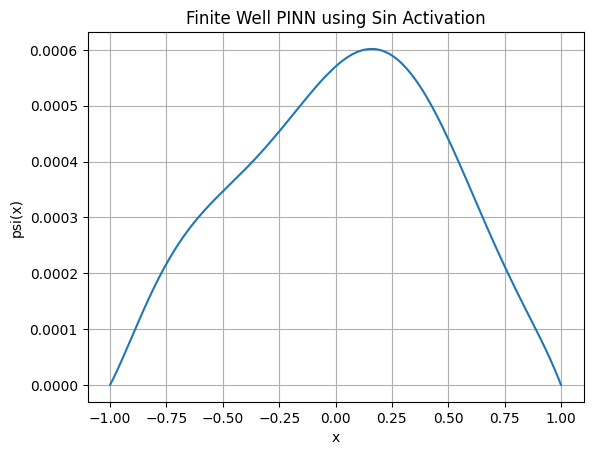

Energy = 1.0466697216033936


In [32]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(1, 32) 
        self.layer2 = nn.Linear(32, 32)
        self.layer3 = nn.Linear(32, 1)
        self.E = nn.Parameter(torch.tensor([1.0]))

    def forward(self, x):
        hidden1 = self.layer1(x)
        activated1 = torch.sin(hidden1)
        hidden2 = self.layer2(activated1)
        activated2 = torch.sin(hidden2)
        nn_output = self.layer3(activated2)
        boundary_condition = 1 - x**2
        psi = boundary_condition * nn_output

        return psi


model = PINN()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5000):

    x = torch.rand(300,1)*2 - 1
    x.requires_grad_(True)

    psi = model(x)

    dpsi = torch.autograd.grad(psi,x,grad_outputs=torch.ones_like(psi),create_graph=True)[0]

    ddpsi = torch.autograd.grad(dpsi,x,grad_outputs=torch.ones_like(dpsi),create_graph=True)[0]

    V = torch.where(torch.abs(x) < 0.5,torch.tensor(0.0),torch.tensor(20.0))

    residual = -ddpsi + V*psi - model.E*psi

    loss_pde = torch.mean(residual**2)

    norm = torch.mean(psi**2) * 2

    loss_norm = (norm - 1)**2

    loss = loss_pde + loss_norm

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(epoch, loss.item(), model.E.item())

x_plot = torch.linspace(-1,1,1000).reshape(-1,1)

with torch.no_grad():
    psi_plot = model(x_plot)

plt.plot(x_plot.numpy(), psi_plot.numpy())
plt.xlabel("x")
plt.ylabel("psi(x)")
plt.title("Finite Well PINN using Sin Activation")
plt.grid()
plt.show()

print("Energy =", model.E.item())

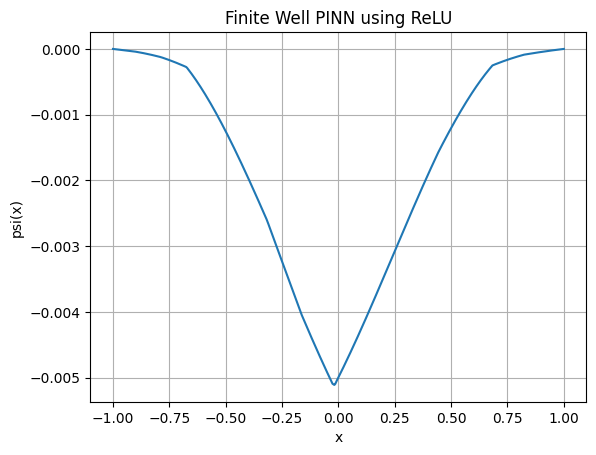

Energy = 1.0704588890075684


In [31]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class PINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1,32),
            nn.ReLU(),
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )

        self.E = nn.Parameter(torch.tensor([1.0]))

    def forward(self,x):
        return (1-x**2)*self.net(x)

model = PINN()

optimizer = torch.optim.Adam(model.parameters(),lr=0.01)

for epoch in range(3000):

    x = torch.rand(200,1)*2 - 1
    x.requires_grad_(True)

    psi = model(x)

    dpsi = torch.autograd.grad(
        psi,
        x,
        grad_outputs=torch.ones_like(psi),
        create_graph=True
    )[0]

    ddpsi = torch.autograd.grad(
        dpsi,
        x,
        grad_outputs=torch.ones_like(dpsi),
        create_graph=True
    )[0]

    V = torch.where(
        torch.abs(x) < 0.5,
        torch.tensor(0.0),
        torch.tensor(20.0)
    )

    residual = -ddpsi + V*psi - model.E*psi

    loss_pde = torch.mean(residual**2)

    loss_norm = (torch.mean(psi**2)*2 - 1)**2

    loss = loss_pde + loss_norm

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

x_plot = torch.linspace(-1,1,500).reshape(-1,1)

with torch.no_grad():
    psi_plot = model(x_plot)

plt.plot(x_plot.numpy(),psi_plot.numpy())
plt.xlabel("x")
plt.ylabel("psi(x)")
plt.title("Finite Well PINN using ReLU")
plt.grid()
plt.show()

print("Energy =",model.E.item())